In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('Placement.csv')

In [3]:
df.head()

,Student_ID,CGPA,IQ,Placement
0,1,6.8,123,1
1,2,5.9,106,0
2,3,5.3,121,0
3,4,7.4,132,1
4,5,5.8,142,0


In [5]:
df.shape

(100, 4)

In [8]:
#steps

#1. Preprocessing + EDA + Feature Extraction
#2. Extract inp and out coln
#3. Scale the Value
#4. Train the model
#5. Evaluate the model/ model selection
#6. Deploy the model

In [9]:
df.info

<bound method DataFrame.info of     Student_ID  CGPA   IQ  Placement
0            1   6.8  123          1
1            2   5.9  106          0
2            3   5.3  121          0
3            4   7.4  132          1
4            5   5.8  142          0
..         ...   ...  ...        ...
95          96   4.3  200          0
96          97   4.4   42          0
97          98   6.7  182          1
98          99   6.3  103          1
99         100   6.2  113          1

[100 rows x 4 columns]>

In [10]:
df = df.iloc[:,1:]

In [11]:
df.head()

,CGPA,IQ,Placement
0,6.8,123,1
1,5.9,106,0
2,5.3,121,0
3,7.4,132,1
4,5.8,142,0


In [12]:
import matplotlib.pyplot as plt

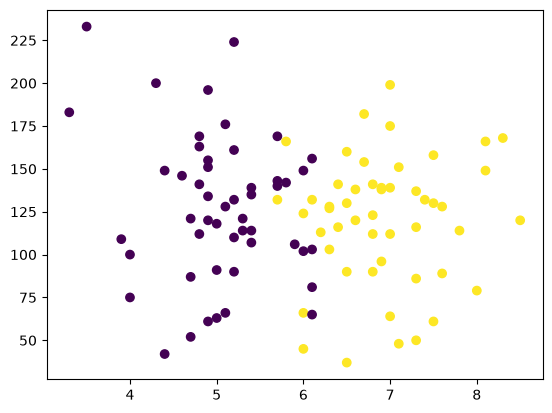

In [15]:
plt.scatter(df['CGPA'], df['IQ'], c = df['Placement'])

In [16]:
X = df.iloc[:,0:2]
Y = df.iloc[:, -1]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.1)

In [23]:
X_train

,CGPA,IQ
38,6.5,160
31,3.9,109
84,5.7,169
69,8.5,120
29,7.0,112
...,...,...
77,7.3,50
70,6.3,127
52,7.0,175
55,7.8,114


In [24]:
Y_train

38    1
31    0
84    0
69    1
29    1
     ..
77    1
70    1
52    1
55    1
19    0
Name: Placement, Length: 90, dtype: int64

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [27]:
X_train = scaler.fit_transform(X_train)

In [28]:
X_train

array([[ 0.37962369,  0.93138773],
       [-1.9276995 , -0.34513353],
       [-0.33032191,  1.15665619],
       [ 2.15448768, -0.06980541],
       [ 0.82333969, -0.27004404],
       [-2.2826723 ,  2.75856522],
       [ 0.64585329,  0.00528407],
       [ 0.02465089,  0.23055253],
       [ 1.79951488,  0.65605962],
       [-1.04026751,  0.80623859],
       [-1.5727267 ,  1.93258087],
       [ 0.11339409, -0.24501421],
       [-0.77403791,  2.53329676],
       [-1.12901071,  1.00647722],
       [-0.86278111, -1.42141615],
       [ 0.82333969, -1.47147581],
       [-0.33032191,  0.50588065],
       [ 1.35579888, -0.8457301 ],
       [-1.8389563 , -0.57040198],
       [-0.06409231, -1.94704255],
       [ 0.64585329, -0.82070027],
       [ 0.82333969,  1.90755105],
       [ 0.02465089,  0.83126842],
       [-0.95152431, -0.11986507],
       [-0.15283551, -0.42022301],
       [ 0.55711009,  1.48204396],
       [-1.48398351, -2.02213204],
       [ 0.37962369,  0.18049287],
       [-0.86278111,

In [29]:
X_test = scaler.fit_transform(X_test)

In [30]:
X_test

array([[ 1.6000054 ,  0.27789062],
       [ 0.14545504, -0.45056052],
       [-0.37402724,  0.08903292],
       [-2.03637051,  1.41103684],
       [ 0.56104085,  0.30487029],
       [-0.58182014, -2.12330018],
       [ 1.49610894,  0.62862635],
       [-0.16623433,  1.22217914],
       [-0.37402724, -0.28868249],
       [-0.27013078, -1.07109297]])

In [39]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()

clf.fit(X_train, Y_train)  #Model Training

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [40]:
Y_pred = clf.predict(X_test)

In [41]:
Y_test

43    1
41    0
40    0
17    0
4     0
94    0
74    1
15    0
22    0
25    0
Name: Placement, dtype: int64

In [42]:
from sklearn.metrics import accuracy_score


In [43]:
accuracy_score(Y_test,Y_pred)

0.8

In [44]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

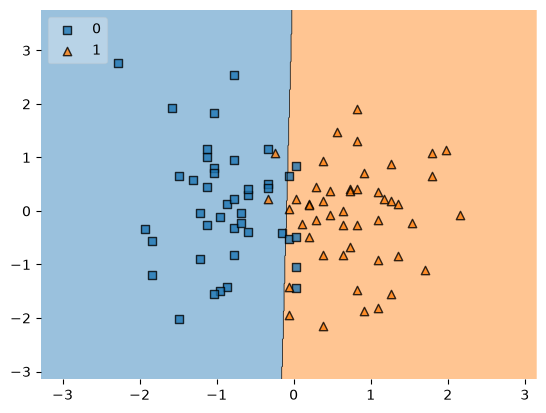

In [45]:
plot_decision_regions(X_train, Y_train.values, clf = clf, legend = 2)

In [46]:
import pickle

In [47]:
pickle.dump(clf,open('model.pkl','wb'))